# Classifying Handwritten Digits with a Neural Network

In this notebook we train a **Multi-Layer Perceptron (MLP)** — one of the simplest kinds of neural network — to recognise handwritten digits from the famous **MNIST dataset**.

MNIST contains 70,000 greyscale images, each 28×28 pixels, showing a single handwritten digit (0–9). 60,000 are used for training and 10,000 for testing.

By the end of this notebook you will have:
- Loaded and visualised the MNIST data
- Built a flexible MLP whose depth and width you can easily change
- Visualised the network's weights **before** and **after** training to see what it has learned
- Explored how classification accuracy changes with the amount of training data
- Compared networks of different depth and width

## 1. Imports and Setup

We use four libraries:
- **torch** — the core PyTorch library for building and training neural networks
- **torchvision** — PyTorch's companion library with image datasets (like MNIST) and preprocessing tools called "transforms"
- **numpy** — numerical arrays (used mainly for reshaping weights for plotting)
- **matplotlib** — plotting

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import random

# Fix random seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


## 2. Load the MNIST Dataset

Each image is a 28×28 grid of pixel values (0 = black, 255 = white). We apply two pre-processing steps:

1. **ToTensor** — converts each image from a NumPy array to a PyTorch tensor and rescales pixel values from [0, 255] to [0, 1].
2. **Normalize** — shifts and scales the pixel values so that the dataset has mean ≈ 0 and standard deviation ≈ 1. This ensures all pixels are on similar numerical scales, which helps the network train faster and more stably — analogous to normalising variables before a least-squares fit.

In [2]:
# Define the sequence of pre-processing steps applied to every image
transform = transforms.Compose([
    transforms.ToTensor(),                        # pixel values -> [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))    # subtract mean, divide by std
])

# Download (first run only) and load the training and test sets
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# DataLoaders serve data in mini-batches during training.
# batch_size=64 means the network sees 64 images at a time before updating its weights.
# Larger batches give smoother but slower updates; smaller batches are noisier but faster.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print(f"Training images : {len(train_dataset):,}")
print(f"Test images     : {len(test_dataset):,}")

Training images : 60,000
Test images     : 10,000


Let's look at a few examples to get a feel for the data.

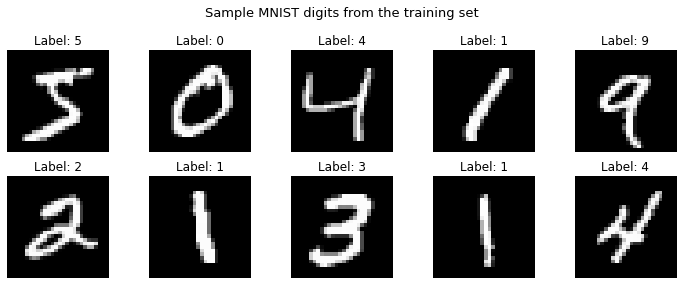

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# axes is a 2D array of subplots (2 rows, 5 columns).
# .flat converts it to a 1D sequence so we can loop over all 10 subplots simply.
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]

    # img has shape (1, 28, 28): channel x height x width.
    # The leading 1 is the colour channel (greyscale has only one channel).
    # .squeeze() removes dimensions of size 1, giving shape (28, 28).
    # We do this because matplotlib's imshow() expects a 2D array, not 3D.
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.suptitle("Sample MNIST digits from the training set", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Define the Network

A **Multi-Layer Perceptron** is a chain of *fully connected* (or *linear*) layers. Each layer applies a linear transformation followed by a non-linear *activation function*.

Here we use the **ReLU** (Rectified Linear Unit) activation: $f(x) = \max(0, x)$. It converts negative values to zero and passes positive values unchanged — neurons effectively "turn on" (pass signal) or "turn off" (block signal). ReLU is popular because it is simple, fast to compute, and works well in practice.

Our network structure:

```
Input (784)  ->  Hidden layer 1  ->  Hidden layer 2  ->  ...  ->  Output (10)
```

- **Input size = 784** because each 28×28 image is flattened into a vector of 784 numbers.
- **Output size = 10** because there are 10 digit classes (0–9).

The `hidden_sizes` argument lets you control the number and size of hidden layers — we will use this later to compare different architectures.

In [5]:
class MLP(nn.Module):
    """
    A flexible Multi-Layer Perceptron for MNIST digit classification.

    Parameters
    ----------
    hidden_sizes : list of int
        Number of neurons in each hidden layer.
        E.g. [128, 64] creates two hidden layers with 128 and 64 neurons.
    """
    def __init__(self, hidden_sizes=[128, 64]):
        super(MLP, self).__init__()

        # Build the full sequence of layer widths: input -> hidden layers -> output
        layer_sizes = [784] + hidden_sizes + [10]

        layers = []
        for i in range(len(layer_sizes) - 1):
            # Linear layer computes: output = weight_matrix @ input + bias
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))

            # Add a ReLU after every hidden layer (not after the final output layer)
            if i < len(layer_sizes) - 2:
                layers.append(nn.ReLU())

        # nn.Sequential(*layers) chains the layers so data flows through them in order.
        # The * operator unpacks the list into separate arguments, which Sequential requires.
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # .view(-1, 784) reshapes the input tensor.
        # 784 = 28*28: we flatten each 2D image into a 1D vector of 784 pixel values.
        # The -1 tells PyTorch to infer the batch size automatically.
        x = x.view(-1, 784)
        return self.network(x)


# Create a default model and inspect it
model = MLP(hidden_sizes=[128, 64])
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total trainable parameters: 109,386


## 4. Visualise Weights — Before Training

Each neuron in the **first hidden layer** has one weight for every pixel in the input image — that is, 784 weights.

If we reshape those 784 weights back into a 28×28 grid, we can display them as an image. Red means a large positive weight (pixel strongly excites the neuron), blue means a large negative weight (pixel strongly suppresses it).

Think of each neuron as a **matched filter**: positive weights highlight pixels that look like features the neuron is learning to detect (e.g. a stroke or curve), while negative weights suppress contradictory patterns. This is directly analogous to cross-correlation templates used in signal processing and image analysis.

Before training, the weights are set randomly, so the images look like noise. After training we expect to see structured patterns.

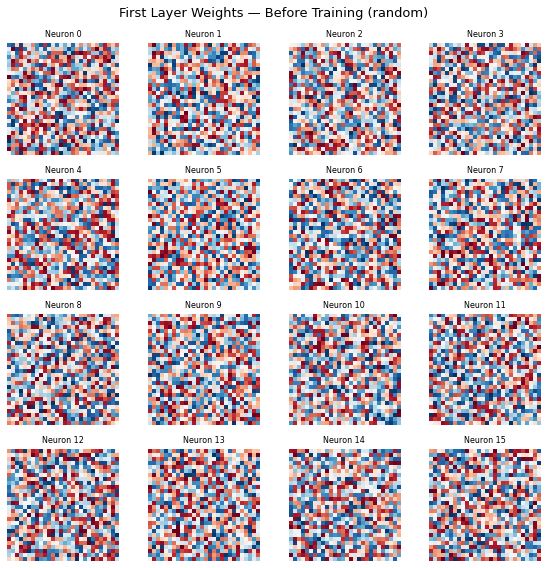

In [6]:
def plot_first_layer_weights(model, title="First Layer Weights"):
    """
    Display the first 16 neurons' input weights as 28x28 images.
    Red = positive weight, Blue = negative weight.
    """
    # Find the first Linear layer in the network
    first_linear = None
    for layer in model.network:
        if isinstance(layer, nn.Linear):
            first_linear = layer
            break

    # .detach() tells PyTorch we don't need gradient information — just the raw values.
    # .numpy() converts the PyTorch tensor into a NumPy array so we can reshape and plot it.
    weights = first_linear.weight.detach().numpy()  # shape: (n_neurons, 784)

    n_show = 16
    vmax = np.abs(weights[:n_show]).max()  # use a symmetric colour scale (red/blue)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):  # .flat converts the 2D grid of axes to a 1D sequence
        w = weights[i].reshape(28, 28)  # reshape 784 weights back into a 28x28 image
        ax.imshow(w, cmap='RdBu', vmin=-vmax, vmax=vmax)
        ax.axis('off')
        ax.set_title(f"Neuron {i}", fontsize=8)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_first_layer_weights(model, title="First Layer Weights — Before Training (random)")

## 5. Train the Network

Training adjusts the network's weights to minimise a **loss function** that measures how wrong the predictions are.

We use:
- **Cross-entropy loss** — the standard loss for classification. It is large when the network is confident but wrong, and small when the network correctly predicts with high confidence. You can think of it like a chi-squared statistic: it heavily penalises predictions that are both wrong *and* confident, pushing the network to only express high confidence when the data justify it.
- **Adam optimiser** — an algorithm that automatically adapts the learning rate for each weight. It is a practical default that works well without much tuning.

Training proceeds in **epochs** — one epoch = one full pass through the training set.

In [7]:
def evaluate(model, loader):
    """Return the classification accuracy (%) on the given dataset."""
    model.eval()   # disable weight updates; we are just running the network, not training it
    correct = 0
    total = 0
    with torch.no_grad():   # tell PyTorch not to track gradients (saves memory during evaluation)
        for images, labels in loader:
            outputs = model(images)

            # The network outputs 10 numbers (one per digit class).
            # The predicted class is whichever has the largest value.
            # .argmax(dim=1) finds the index of the maximum along dimension 1
            # (dimension 0 is the batch; dimension 1 is the 10 class scores).
            predicted = outputs.argmax(dim=1)

            # .item() converts the PyTorch tensor result into a plain Python number
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total


def train(model, train_loader, test_loader, n_epochs=10, lr=0.001, verbose=True):
    """
    Train `model` and return the per-epoch training loss and test accuracy.

    Parameters
    ----------
    model        : MLP instance
    train_loader : DataLoader for training data
    test_loader  : DataLoader for test data (used to evaluate accuracy each epoch)
    n_epochs     : number of full passes through the training set
    lr           : learning rate
    verbose      : print progress each epoch if True
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses     = []
    accuracies = []

    for epoch in range(n_epochs):
        model.train()   # enable weight updates for this training pass
        epoch_loss = 0.0

        for images, labels in train_loader:
            # 1. Clear gradients from the previous batch.
            #    PyTorch accumulates gradients by default, so we must reset them each step.
            optimizer.zero_grad()

            # 2. Forward pass: run images through the network to get predictions
            outputs = model(images)

            # 3. Compute how wrong the predictions are
            loss = criterion(outputs, labels)

            # 4. Backward pass: use the chain rule to compute how much each weight
            #    contributed to the error (these are called gradients)
            loss.backward()

            # 5. Update each weight by a small step in the direction that reduces the loss
            optimizer.step()

            epoch_loss += loss.item()  # .item() converts tensor to a plain Python number

        avg_loss = epoch_loss / len(train_loader)
        acc      = evaluate(model, test_loader)
        losses.append(avg_loss)
        accuracies.append(acc)

        if verbose:
            print(f"Epoch {epoch + 1:2d}/{n_epochs}  |  Loss: {avg_loss:.4f}  |  Test accuracy: {acc:.2f}%")

    return losses, accuracies

In [ ]:
# Train for 10 epochs — this typically takes 1-2 minutes on a CPU
model = MLP(hidden_sizes=[128, 64])
losses, accuracies = train(model, train_loader, test_loader, n_epochs=10)

In [ ]:
epochs = range(1, len(losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Over Time')
ax1.grid(True)

ax2.plot(epochs, accuracies, 'r-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Over Time')
ax2.set_ylim([0, 100])
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. Visualise Weights — After Training

Now let's look at the same first-layer weights after training. The random noise should be replaced by structured patterns — the network has learned which pixel regions are informative for distinguishing digits.

In [ ]:
plot_first_layer_weights(model, title="First Layer Weights — After Training")

## 7. How Much Training Data Do We Need?

Intuitively, more training data should lead to better generalisation. Here we train separate models on different fractions of the training set and compare their test accuracies.

This is directly analogous to signal detection in astronomy: just as deeper observations yield better signal-to-noise and allow fainter sources to be detected, more training examples allow the network to learn finer distinctions between digit classes. How many examples do we need before performance levels off?

In [ ]:
fractions = [0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0]
fraction_accuracies = []

for frac in fractions:
    n_samples = int(len(train_dataset) * frac)

    # Randomly select n_samples indices from the full training set
    indices = random.sample(range(len(train_dataset)), n_samples)
    subset  = Subset(train_dataset, indices)
    subset_loader = DataLoader(subset, batch_size=64, shuffle=True)

    # Fresh model and train on the subset
    m = MLP(hidden_sizes=[128, 64])
    train(m, subset_loader, test_loader, n_epochs=10, verbose=False)
    acc = evaluate(m, test_loader)
    fraction_accuracies.append(acc)

    print(f"{frac:5.0%} of training data  ({n_samples:,} images)  ->  Test accuracy: {acc:.2f}%")

# Plot accuracy vs number of training images on a log scale
plt.figure(figsize=(8, 5))
plt.plot([f * len(train_dataset) for f in fractions], fraction_accuracies, 'g-o')
plt.xscale('log')
plt.xlabel('Number of Training Images (log scale)')
plt.ylabel('Test Accuracy (%)')
plt.title('Classification Accuracy vs. Amount of Training Data')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. How Does Network Depth and Width Affect Performance?

The **width** of a layer is the number of neurons in it — more neurons means more capacity to represent complex patterns, but also more parameters to train.

The **depth** is the number of hidden layers. Deeper networks can represent more hierarchical features, but they are harder to train.

More parameters often allow a network to fit more complex patterns, but can also lead to **overfitting** — memorising the training data rather than learning general features that transfer to new examples. Let's see how depth and width affect both capacity and actual test performance.

| Architecture | Hidden layers | Approx. parameters |
|---|---|---|
| Shallow & Narrow | [64] | ~51 k |
| Shallow & Wide | [512] | ~407 k |
| Deep & Narrow | [64, 64, 64] | ~55 k |
| Deep & Wide | [256, 128, 64] | ~234 k |

In [ ]:
architectures = {
    "Shallow & Narrow  [64]": [64],
    "Shallow & Wide  [512]": [512],
    "Deep & Narrow  [64, 64, 64]": [64, 64, 64],
    "Deep & Wide  [256, 128, 64]": [256, 128, 64],
}

arch_results = {}

for name, hidden_sizes in architectures.items():
    m = MLP(hidden_sizes=hidden_sizes)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"\nTraining: {name}  ({n_params:,} parameters)")
    _, accs = train(m, train_loader, test_loader, n_epochs=10, verbose=False)
    arch_results[name] = accs
    print(f"  Final test accuracy: {accs[-1]:.2f}%")

# Plot all learning curves on the same axes for comparison
plt.figure(figsize=(10, 5))
for name, accs in arch_results.items():
    plt.plot(range(1, len(accs) + 1), accs, '-o', label=name)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of Network Depth and Width on Performance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Classify a Single Image

Set `image_index` to any number between 0 and 9,999 to pick an image from the test set, then run the cell to see the network's prediction.

The bar chart shows the network's output score for each digit class — the tallest bar is the predicted digit.

In [ ]:
# -------------------------------------------------------
# Change this number to select a different test image
# Any integer from 0 to 9,999
image_index = 455
# -------------------------------------------------------

# Retrieve the image and its true label from the test set
img_tensor, true_label = test_dataset[image_index]

# Run the image through the trained network
# .unsqueeze(0) adds a batch dimension: shape goes from (1,28,28) to (1,1,28,28)
model.eval()
with torch.no_grad():
    logits = model(img_tensor.unsqueeze(0))  # raw scores, shape (1, 10)

# Convert raw scores to probabilities using softmax
# softmax turns any set of numbers into positive values that sum to 1 (like probabilities)
probs = torch.softmax(logits, dim=1).squeeze().numpy()  # shape (10,)
predicted_digit = int(probs.argmax())

# --- Plot ---
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 3),
                                      gridspec_kw={'width_ratios': [1, 2.5]})

# Left panel: the image itself
ax_img.imshow(img_tensor.squeeze(), cmap='gray')
ax_img.set_title(f'Test image #{image_index}\nTrue label: {true_label}', fontsize=11)
ax_img.axis('off')

# Right panel: confidence bar chart
colours = ['tab:blue'] * 10
colours[predicted_digit] = 'tab:orange'  # highlight the predicted class
ax_bar.bar(range(10), probs, color=colours)
ax_bar.set_xticks(range(10))
ax_bar.set_xlabel('Digit class')
ax_bar.set_ylabel('Confidence')
ax_bar.set_ylim(0, 1)
ax_bar.set_title(
    f'Predicted: {predicted_digit}  '
    f'({"correct" if predicted_digit == true_label else "WRONG"})\n'
    f'Confidence: {probs[predicted_digit]:.1%}',
    fontsize=11
)
ax_bar.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Also print a text summary
print(f'True label : {true_label}')
print(f'Predicted  : {predicted_digit}  ({"correct" if predicted_digit == true_label else "WRONG"})')
print()
print('Confidence scores:')
for digit, p in enumerate(probs):
    marker = ' <-- predicted' if digit == predicted_digit else ''
    print(f'  Digit {digit}: {p:.1%}{marker}')


## 10. Draw Your Own Digit

Click and drag on the canvas below to draw a digit. The network classifies it automatically when you release the mouse. Hit **Clear** to start again.

> **Backend note:** This cell needs an interactive matplotlib backend.
> - **Classic Jupyter Notebook** (Anaconda default): the `%matplotlib notebook` line below works as-is.
> - **JupyterLab**: replace `%matplotlib notebook` with `%matplotlib widget` and first run `conda install -c conda-forge ipympl` in your terminal, then restart the kernel.

In [ ]:
# Switch to an interactive backend so mouse events are captured.
# Classic Jupyter Notebook: use the line below as-is.
# JupyterLab: change to  %matplotlib widget  (requires ipympl).
%matplotlib notebook

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

# ---- Drawing state ----
canvas   = np.zeros((28, 28), dtype=np.float32)  # 0 = background, 1 = ink
drawing  = [False]   # use a list so nested functions can update it
last_pos = [None]    # last (x, y) position while dragging

# ---- Figure layout ----
fig = plt.figure(figsize=(9, 3.8))
ax_canvas = fig.add_axes([0.03, 0.18, 0.38, 0.74])  # drawing area
ax_clear  = fig.add_axes([0.03, 0.04, 0.38, 0.10])  # clear button
ax_result = fig.add_axes([0.48, 0.12, 0.50, 0.80])  # classification output

# Initialise canvas display (white ink on dark background, MNIST style)
ax_canvas.set_xlim(-0.5, 27.5)
ax_canvas.set_ylim(27.5, -0.5)   # flip y so (0,0) is top-left
ax_canvas.set_xticks([])
ax_canvas.set_yticks([])
ax_canvas.set_title('Draw a digit here\n(click and drag, release to classify)')
canvas_img = ax_canvas.imshow(canvas, cmap='gray', vmin=0, vmax=1,
                               extent=[-0.5, 27.5, 27.5, -0.5])

btn = Button(ax_clear, 'Clear', color='lightcoral', hovercolor='salmon')

ax_result.set_title('Draw a digit to see the prediction', fontsize=11)
ax_result.axis('off')


# ---- Drawing helpers ----

def paint(x, y, radius=1.8):
    """
    Add ink at canvas coordinates (x, y) using a soft round brush.
    Pixels closer to the centre get more ink (gradient falloff).
    """
    for px in range(max(0, int(x)-3), min(28, int(x)+4)):
        for py in range(max(0, int(y)-3), min(28, int(y)+4)):
            dist = np.sqrt((px - x)**2 + (py - y)**2)
            if dist <= radius:
                canvas[py, px] = min(1.0, canvas[py, px] + 0.9 * (1 - dist / radius))


def paint_segment(x0, y0, x1, y1):
    """
    Paint a line of brush strokes from (x0,y0) to (x1,y1).
    Interpolating prevents gaps when the mouse moves quickly.
    """
    steps = max(1, int(np.hypot(x1 - x0, y1 - y0) * 2))
    for i in range(steps + 1):
        t = i / steps
        paint(x0 + t * (x1 - x0), y0 + t * (y1 - y0))


# ---- Classification ----

def classify():
    """
    Convert the drawn canvas to a tensor, apply the same normalisation
    used during training, run the network, and display the result.
    """
    # canvas is (28, 28) with values in [0, 1]
    # Add batch and channel dimensions: (1, 1, 28, 28)
    img = torch.tensor(canvas).unsqueeze(0).unsqueeze(0)

    # Apply the same normalisation used when loading MNIST:
    # Normalize(mean=0.1307, std=0.3081)
    img = (img - 0.1307) / 0.3081

    model.eval()
    with torch.no_grad():
        logits = model(img)                             # raw output scores
    probs     = torch.softmax(logits, dim=1).squeeze().numpy()  # probabilities
    predicted = int(probs.argmax())

    # Update bar chart
    colours = ['tab:blue'] * 10
    colours[predicted] = 'tab:orange'
    ax_result.cla()
    ax_result.bar(range(10), probs, color=colours)
    ax_result.set_xticks(range(10))
    ax_result.set_xlabel('Digit class')
    ax_result.set_ylabel('Confidence')
    ax_result.set_ylim(0, 1)
    ax_result.set_title(f'Predicted: {predicted}   Confidence: {probs[predicted]:.1%}',
                         fontsize=11)
    ax_result.grid(axis='y', alpha=0.4)
    fig.canvas.draw_idle()


# ---- Mouse event callbacks ----

def on_press(event):
    if event.inaxes == ax_canvas and event.button == 1:
        drawing[0] = True
        paint(event.xdata, event.ydata)
        last_pos[0] = (event.xdata, event.ydata)
        canvas_img.set_data(canvas)
        fig.canvas.draw_idle()


def on_motion(event):
    if drawing[0] and event.inaxes == ax_canvas and event.xdata is not None:
        x, y = event.xdata, event.ydata
        if last_pos[0] is not None:
            paint_segment(*last_pos[0], x, y)  # fill gaps between mouse samples
        else:
            paint(x, y)
        last_pos[0] = (x, y)
        canvas_img.set_data(canvas)
        fig.canvas.draw_idle()


def on_release(event):
    if event.button == 1:
        drawing[0] = False
        last_pos[0] = None
        if canvas.max() > 0:   # only classify if something was drawn
            classify()


def on_clear(event):
    canvas[:] = 0.0
    canvas_img.set_data(canvas)
    ax_result.cla()
    ax_result.set_title('Cleared — draw a new digit', fontsize=11)
    ax_result.axis('off')
    fig.canvas.draw_idle()


fig.canvas.mpl_connect('button_press_event',   on_press)
fig.canvas.mpl_connect('motion_notify_event',  on_motion)
fig.canvas.mpl_connect('button_release_event', on_release)
btn.on_clicked(on_clear)

plt.show()


## Summary

In this notebook we:

1. **Loaded MNIST** — 60,000 labelled images of handwritten digits.
2. **Built an MLP** — a chain of linear layers and ReLU activations, flexible in depth and width.
3. **Visualised weights before training** — random noise with no structure.
4. **Trained the network** using cross-entropy loss and the Adam optimiser, watching loss decrease and accuracy increase.
5. **Visualised weights after training** — structured patterns reflecting which pixel regions matter for each neuron.
6. **Measured the effect of training set size** — accuracy improves roughly logarithmically with data.
7. **Compared architectures** — wider and deeper networks generally perform better on this task, up to a point.

### Things to try
- Change `hidden_sizes` in the first `MLP(...)` call to a single layer or a very wide network.
- Reduce `n_epochs` to 2 or 3 — how quickly does the model learn most of what it can learn?
- Try a higher learning rate (`lr=0.01`) — does training become unstable?
- Look at specific test images the model gets **wrong** — do they make sense to you?